In [1]:
import cupy as cu_np
from cupyx.scipy.ndimage import prewitt, map_coordinates
# Note: CuPy's map_coordinates is less feature-rich than SciPy's,
# but it should work for standard cases like this.

def warp_image(image, p):
    """
    Warps an image according to the motion vector p = [h, v, theta] using CuPy.
    """
    # Ensure p is on the device if it came from the host
    p = cu_np.asarray(p)
    h, v, theta = p
    
    # Use CuPy's np.indices, which returns CuPy arrays (on GPU)
    n2_out, n1_out = cu_np.indices(image.shape)

    cos_t = cu_np.cos(theta)
    sin_t = cu_np.sin(theta)

    # Inverse of Rotate-then-Translate: p_in = R(-t) * (p_out - T)
    n1_rot = n1_out - h
    n2_rot = n2_out - v

    # All arithmetic operations are now performed on the GPU
    n1_in = n1_rot * cos_t + n2_rot * sin_t
    n2_in = -n1_rot * sin_t + n2_rot * cos_t

    coords = cu_np.array([n2_in, n1_in])
    # Use CuPy's map_coordinates
    warped_image = map_coordinates(image, coords, order=3, cval=0.0)

    return warped_image


def register_iterative(y1, yk, iterations=10, min_update_norm=1e-6, step_size=1.0):
    """
    Iteratively estimates motion using a stable "Lucas-Kanade" style approach on GPU (CuPy).
    """

    # --- Initialization on GPU ---
    # Ensure input images and the parameter vector start on the GPU
    if not isinstance(y1, cu_np.ndarray):
        y1 = cu_np.asarray(y1)
    if not isinstance(yk, cu_np.ndarray):
        yk = cu_np.asarray(yk)
        
    p_total = cu_np.zeros(3)  # [h, v, theta] - now a CuPy array on GPU

    # --- 1. Calculate Gradients and A Matrix (Hessian) ONCE on GPU ---
    print("Calculating constant A matrix from reference image y1...")
    # Use CuPy's prewitt
    # gy1 and gx1 are now CuPy arrays
    gy1 = prewitt(y1, axis=0)  # Gradient in y-direction (rows, n2)
    gx1 = prewitt(y1, axis=1)  # Gradient in x-direction (cols, n1)
    n2, n1 = cu_np.indices(y1.shape) # CuPy arrays

    # This correctly matches the paper's Eq. 27
    g_bar1 = (n1 * gy1) - (n2 * gx1)

    # Flatten gradients for summation (CuPy's ravel/sum)
    gx1_f = gx1.ravel()
    gy1_f = gy1.ravel()
    g_bar1_f = g_bar1.ravel()

    # Construct the constant 3x3 Matrix A on GPU
    # All element-wise products and sums are performed on the GPU
    A11 = cu_np.sum(gx1_f * gx1_f)
    A12 = cu_np.sum(gx1_f * gy1_f)
    A13 = cu_np.sum(gx1_f * g_bar1_f)
    A22 = cu_np.sum(gy1_f * gy1_f)
    A23 = cu_np.sum(gy1_f * g_bar1_f)
    A33 = cu_np.sum(g_bar1_f * g_bar1_f)

    A = (cu_np.array([
        [A11, A12, A13],
        [A12, A22, A23],
        [A13, A23, A33]
    ]))

    print(f"Starting iterative registration (step_size = {step_size})...")
    print(f" iter | {'h (pix)':<10} | {'v (pix)':<10} | {'theta (rad)':<10} | {'Update Norm':<12}")
    print("-" * 58)

    for i in range(iterations):
        yk_warped = warp_image(yk, p_total)

        # 1. The error vector is (current - target)
        diff_image = yk_warped - y1
        diff_image_f = diff_image.ravel()

        # b = G^T * e (Calculations on GPU)
        b1 = cu_np.sum(diff_image_f * gx1_f)
        b2 = cu_np.sum(diff_image_f * gy1_f)
        b3 = cu_np.sum(diff_image_f * g_bar1_f)
        b = cu_np.array([b1, b2, b3]) # CuPy array

        try:
            # p_update = A_inv * b (CuPy's linalg.solve runs on GPU)
            p_update = cu_np.linalg.solve(A, b)
        except cu_np.linalg.LinAlgError:
            # Convert to Python list/scalar for printing if needed, or just print the CuPy error
            print(f"Error: Matrix A is singular at iteration {i}.")
            p_update = cu_np.zeros(3)

        # 2. Update p_total (on GPU)
        p_total = p_total + (step_size * p_update)

        # np.linalg.norm runs on GPU
        update_norm = cu_np.linalg.norm(p_update)
        
        # We fetch only the necessary values from the GPU to the host for printing
        h, v, theta = p_total.get()
        print(f" {i:<4} | {h:<10.4f} | {v:<10.4f} | {theta:<10.6f} | {update_norm.get():<12.8f}")

        if update_norm < min_update_norm:
            print(f"\nConvergence reached in {i + 1} iterations.")
            break

    if i == iterations - 1:
        print(f"\nMaximum iterations reached ({iterations}).")

    # Return the final result as a standard NumPy array (by fetching from GPU)
    return p_total.get()

Creating ground truth test data using the algorithm's model...
Calculating constant A matrix from reference image y1...
Starting iterative registration (step_size = 2.0)...
 iter | h (pix)    | v (pix)    | theta (rad) | Update Norm 
----------------------------------------------------------
 0    | -0.1041    | 0.2371     | -0.000346  | 0.12946707  
 1    | -0.2090    | 0.4751     | -0.000692  | 0.13003203  
 2    | -0.3142    | 0.7134     | -0.001040  | 0.13025050  
 3    | -0.4195    | 0.9516     | -0.001388  | 0.13026417  
 4    | -0.5249    | 1.1898     | -0.001736  | 0.13020806  
 5    | -0.6303    | 1.4277     | -0.002083  | 0.13011934  
 6    | -0.7357    | 1.6653     | -0.002431  | 0.12996849  
 7    | -0.8411    | 1.9025     | -0.002779  | 0.12975713  
 8    | -0.9463    | 2.1392     | -0.003127  | 0.12949205  
 9    | -1.0514    | 2.3753     | -0.003474  | 0.12923188  
 10   | -1.1564    | 2.6110     | -0.003821  | 0.12901730  
 11   | -1.2615    | 2.8463     | -0.004169  | 

 91   | -11.7254   | 23.5221    | -0.035102  | 0.14959282  
 92   | -11.8678   | 23.7861    | -0.035509  | 0.14994966  
 93   | -12.0115   | 24.0511    | -0.035917  | 0.15071696  
 94   | -12.1566   | 24.3175    | -0.036328  | 0.15169481  
 95   | -12.3033   | 24.5853    | -0.036741  | 0.15268909  
 96   | -12.4513   | 24.8543    | -0.037156  | 0.15349625  
 97   | -12.6002   | 25.1240    | -0.037572  | 0.15401700  
 98   | -12.7494   | 25.3938    | -0.037988  | 0.15418296  
 99   | -12.8985   | 25.6633    | -0.038404  | 0.15395972  
 100  | -13.0470   | 25.9318    | -0.038819  | 0.15344840  
 101  | -13.1948   | 26.1993    | -0.039234  | 0.15283035  
 102  | -13.3420   | 26.4660    | -0.039647  | 0.15228152  
 103  | -13.4888   | 26.7319    | -0.040061  | 0.15188451  
 104  | -13.6354   | 26.9975    | -0.040474  | 0.15165160  
 105  | -13.7819   | 27.2629    | -0.040888  | 0.15158078  
 106  | -13.9287   | 27.5283    | -0.041302  | 0.15166488  
 107  | -14.0758   | 27.7940    | -0.041

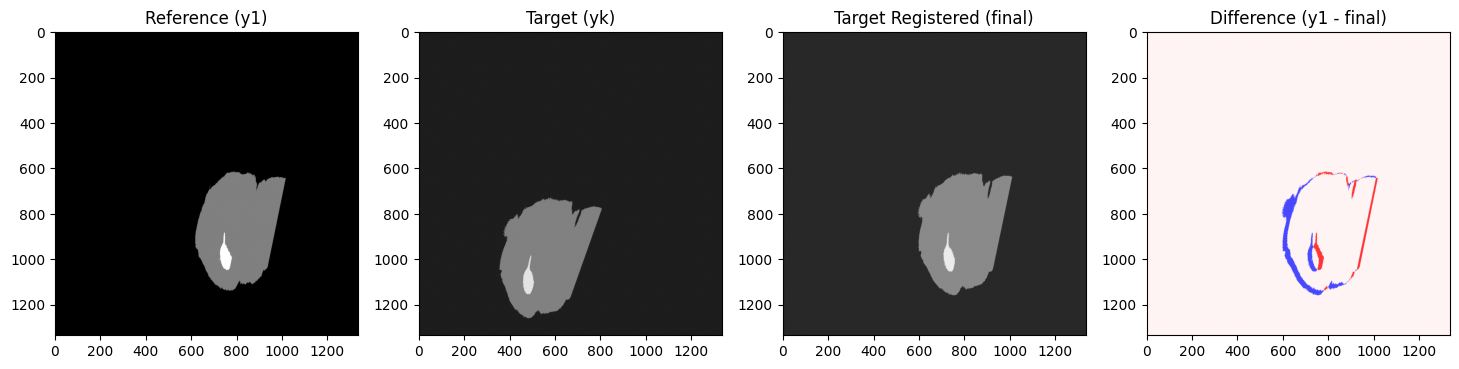

In [ ]:
import cupy as cu_np # Changed numpy to cupy
# ... (all function definitions above) ...

import numpy as np # Keep a reference to CPU numpy if needed
from PIL import Image
from scipy.ndimage import shift, rotate # These are not used in the final registration loop
import matplotlib.pyplot as plt

# --- 1. Load images on CPU (NumPy arrays) ---
y1_cpu = plt.imread('image_260.tif')
y1_cpu = (y1_cpu - y1_cpu.min()) / (y1_cpu.max() - y1_cpu.min())
yk_cpu = plt.imread('image_290.tif')
yk_cpu = (yk_cpu - yk_cpu.min()) / (yk_cpu.max() - yk_cpu.min())

# --- CRITICAL: Transfer data to GPU (CuPy arrays) ---
y1 = cu_np.asarray(y1_cpu)
yk = cu_np.asarray(yk_cpu)


# --- 2. Define ground-truth transformation ---
H_TRUE = 130
V_TRUE = -14
THETA_TRUE_RAD = np.deg2rad(-8) # Use CPU numpy for non-array calculations
p_ground_truth = cu_np.array([H_TRUE, V_TRUE, THETA_TRUE_RAD]) # CuPy array

# --- 3. Apply transformations to create the target image yk ---
print("Creating ground truth test data using the algorithm's model...")
# warp_image now uses CuPy and runs on GPU
yk_transformed = warp_image(yk, -p_ground_truth)


# --- 4. Run the iterative registration ---
# The function now runs entirely on the GPU
# p_final is returned to CPU (NumPy array)
p_final_cpu = register_iterative(y1, yk_transformed, iterations=1000, step_size=2.0) 
print("@@@@@@@@@@@@@@@@@@")
h_est, v_est, theta_est_rad = p_final_cpu
theta_est_deg = np.rad2deg(theta_est_rad)

print(y1.shape, yk_transformed.shape, p_final_cpu.shape )
print(y1, yk_transformed, p_final_cpu )

# --- 6. Show final warped image ---
final_warped_image_gpu = warp_image(yk_transformed, p_final_cpu)
# Transfer final result back to CPU for plotting
final_warped_image_cpu = final_warped_image_gpu.get()
yk_transformed_cpu = yk_transformed.get()

# Plotting uses CPU NumPy arrays
plt.figure(figsize=(18, 5))
plt.subplot(1, 4, 1)
plt.imshow(y1_cpu, cmap='gray')
plt.title("Reference (y1)")
plt.subplot(1, 4, 2)
plt.imshow(yk_transformed_cpu, cmap='gray')
plt.title("Target (yk)")
plt.subplot(1, 4, 3)
plt.imshow(final_warped_image_cpu, cmap='gray')
plt.title("Target Registered (final)")
plt.subplot(1, 4, 4)
plt.imshow(y1_cpu - final_warped_image_cpu, cmap='bwr')
plt.title("Difference (y1 - final)")
plt.show()

In [ ]:
import cupy as cp
import numpy as cpu_np

# 3D Rigid Transformation Model: R(theta) * x + T

import cupy as cp


import cupy as cp

def get_rotation_matrix(theta_x, theta_y, theta_z):
    """
    Constructs a 3D rotation matrix (Z-Y-X Euler angles) on the GPU (CuPy).
    Uses explicit stack operations to bypass the TypeError in cp.array/Python lists.
    """
    # 1. Trigonometric values (CuPy scalars)
    cos_x, sin_x = cp.cos(theta_x), cp.sin(theta_x)
    cos_y, sin_y = cp.cos(theta_y), cp.sin(theta_y)
    cos_z, sin_z = cp.cos(theta_z), cp.sin(theta_z)

    # Helper for creating zero/one constant row arrays
    Z = cp.zeros_like(cos_x) # 0.0, but as a 0D CuPy array
    O = cp.ones_like(cos_x)  # 1.0, but as a 0D CuPy array
    
    # 2. Rotation around X-axis (Rx)
    # Stacking 1D arrays (rows) composed of CuPy scalars (0D arrays)
    Rx = cp.stack([
        cp.stack([O, Z, Z]), # [1, 0, 0]
        cp.stack([Z, cos_x, -sin_x]), # [0, cos_x, -sin_x]
        cp.stack([Z, sin_x, cos_x]) # [0, sin_x, cos_x]
    ])
    # The result is a (3, 3) CuPy array.

    # 3. Rotation around Y-axis (Ry)
    Ry = cp.stack([
        cp.stack([cos_y, Z, sin_y]),
        cp.stack([Z, O, Z]),
        cp.stack([-sin_y, Z, cos_y])
    ])

    # 4. Rotation around Z-axis (Rz)
    Rz = cp.stack([
        cp.stack([cos_z, -sin_z, Z]),
        cp.stack([sin_z, cos_z, Z]),
        cp.stack([Z, Z, O])
    ])

    # Combined Rotation (R = Rz @ Ry @ Rx)
    return Rz @ Ry @ Rx


def warp_point_cloud_3d(points, p):
    """
    Warps a 3D point cloud (N x 3) according to the motion vector 
    p = [h, v, w, theta_x, theta_y, theta_z] using CuPy.

    points: CuPy array of shape (N, 3), where points[:, 0]=x, points[:, 1]=y, points[:, 2]=z.
    p: CuPy array [h, v, w, theta_x, theta_y, theta_z]
    """
    p = cp.asarray(p)
    h, v, w, theta_x, theta_y, theta_z = p
    
    # 1. Rotation Matrix (Inverse for Inverse Compositional)
    # Since we need the inverse warp (W(x; p)^{-1}), we use R(-theta) and T(-T).
    # We apply the inverse transformation R(p)^{-1} * (x - T)
    R_inv = get_rotation_matrix(-theta_z, -theta_y, -theta_x) # Rz(-t_z) @ Ry(-t_y) @ Rx(-t_x)
    T = cp.array([h, v, w])

    # 2. Inverse Translation: (x - T)
    # yk_pc_trans = points - T (broadcasting works)
    yk_pc_trans = points - T
    
    # 3. Inverse Rotation: R_inv * (x - T)
    # points: (N, 3), R_inv: (3, 3). Matrix multiplication needs R_inv @ points.T
    # warped_points = (R_inv @ yk_pc_trans.T).T
    warped_points = cp.einsum('ij,nj->ni', R_inv, yk_pc_trans)

    return warped_points


def register_point_cloud_iterative_3d(y1_pc, yk_pc, iterations=10, min_update_norm=1e-6, step_size=1.0):
    """
    Iteratively estimates 3D motion for point clouds (6 DOF, Lucas-Kanade style).

    y1_pc: Reference Point Cloud (N, 3)
    yk_pc: Moving Point Cloud (N, 3)
    """
            
    # --- Initialization on GPU ---
    if not isinstance(y1_pc, cp.ndarray):
        y1_pc = cp.asarray(y1_pc)
    if not isinstance(yk_pc, cp.ndarray):
        yk_pc = cp.asarray(yk_pc)
            
    p_total = cp.zeros(6)  # [h, v, w, theta_x, theta_y, theta_z]
    N = y1_pc.shape[0]

    # --- 1. Jacobian Matrix J (6x3N) ---
    # Transformation T(x, p) = R(p) * x + T
    # The Jacobian d(T)/d(p) is calculated at the reference configuration y1_pc and p=[0,...,0].
    
    # Points in reference cloud: [x, y, z]
    x_ref = y1_pc[:, 0]
    y_ref = y1_pc[:, 1]
    z_ref = y1_pc[:, 2]
    
    # J_T (Translation components: h, v, w)
    # J_h = [1, 0, 0]^T
    # J_v = [0, 1, 0]^T
    # J_w = [0, 0, 1]^T
    
    # J_R (Rotation components: theta_x, theta_y, theta_z)
    # J_tx = d(R@x)/d(tx) at t=0 = d(Rx)/d(tx) at t=0 = [0, -z, y]^T
    # J_ty = d(R@x)/d(ty) at t=0 = d(Ry)/d(ty) at t=0 = [z, 0, -x]^T
    # J_tz = d(R@x)/d(tz) at t=0 = d(Rz)/d(tz) at t=0 = [-y, x, 0]^T
    
    # J_x (x-component of Jacobian for all 6 parameters) - (N, 6)
    J_x = cp.stack([cp.ones(N), cp.zeros(N), cp.zeros(N), 
                    cp.zeros(N), z_ref, -y_ref], axis=1) # [h, v, w, tx, ty, tz]
                    
    # J_y (y-component of Jacobian) - (N, 6)
    J_y = cp.stack([cp.zeros(N), cp.ones(N), cp.zeros(N), 
                    -z_ref, cp.zeros(N), x_ref], axis=1)
                    
    # J_z (z-component of Jacobian) - (N, 6)
    J_z = cp.stack([cp.zeros(N), cp.zeros(N), cp.ones(N), 
                    y_ref, -x_ref, cp.zeros(N)], axis=1)

    # --- 2. Calculate Hessian Approximation A = J^T * J (6x6 Matrix) ---
    # A = Sum over i: J_i^T * J_i
    # A_jk = Sum_i (J_x[i, j] * J_x[i, k] + J_y[i, j] * J_y[i, k] + J_z[i, j] * J_z[i, k])
    
    print("Calculating constant A matrix (6x6 Hessian approximation)...")
    
    # Initialize A (6, 6)
    A = cp.zeros((6, 6))
    
    # Compute A using outer products and summation
    # A_i = J_x[i,:].T @ J_x[i,:] + J_y[i,:].T @ J_y[i,:] + J_z[i,:].T @ J_z[i,:]
    
    # Combine J_x, J_y, J_z to J (3N, 6)
    J_all = cp.concatenate([J_x, J_y, J_z], axis=0)
    
    # A = J_all.T @ J_all
    # We use cp.einsum for efficient calculation of the sum of outer products:
    # A = Sum_i (J_i.T * J_i) over 3N rows of the Jacobian
    
    # A_jk = Sum_i J_x[i, j] J_x[i, k] + Sum_i J_y[i, j] J_y[i, k] + Sum_i J_z[i, j] J_z[i, k]
    for j in range(6):
        for k in range(j, 6):
            A[j, k] = cp.sum(J_x[:, j] * J_x[:, k]) + \
                      cp.sum(J_y[:, j] * J_y[:, k]) + \
                      cp.sum(J_z[:, j] * J_z[:, k])
            if j != k:
                A[k, j] = A[j, k] # A is symmetric
    
    print(f"Starting iterative 3D point cloud registration (step_size = {step_size})...")
    print(f" iter | {'h':<8} | {'v':<8} | {'w':<8} | {'tx(rad)':<9} | {'ty(rad)':<9} | {'tz(rad)':<9} | {'Update Norm':<12}")
    print("-" * 75)

    for i in range(iterations):
        # 3. Warp the moving point cloud (yk_pc)
        yk_warped = warp_point_cloud_3d(yk_pc, p_total)

        # 4. Calculate the error (residual) vector e = yk_warped - y1_pc
        # This is a (N, 3) array of errors: [e_x, e_y, e_z]
        error_pc = yk_warped - y1_pc
        
        e_x = error_pc[:, 0]
        e_y = error_pc[:, 1]
        e_z = error_pc[:, 2]

        # 5. Calculate b = J^T * e (6x1 vector)
        # b_j = Sum_i (J_x[i, j]*e_x[i] + J_y[i, j]*e_y[i] + J_z[i, j]*e_z[i])
        
        b = cp.zeros(6)
        for j in range(6):
            b[j] = cp.sum(J_x[:, j] * e_x) + \
                   cp.sum(J_y[:, j] * e_y) + \
                   cp.sum(J_z[:, j] * e_z)

        try:
            # 6. Solve for update: p_update = A_inv * b
            p_update = cp.linalg.solve(A, b)
        except cp.linalg.LinAlgError:
            print(f"Error: Matrix A is singular at iteration {i}.")
            p_update = cp.zeros(6)

        # 7. Update p_total
        p_total = p_total + (step_size * p_update)

        update_norm = cp.linalg.norm(p_update)
            
        # We fetch only the necessary values from the GPU to the host for printing
        h, v, w, tx, ty, tz = p_total.get()
        print(f" {i:<4} | {h:<8.3f} | {v:<8.3f} | {w:<8.3f} | {tx:<9.5f} | {ty:<9.5f} | {tz:<9.5f} | {update_norm.get():<12.8f}")

        if update_norm < min_update_norm:
            print(f"\nConvergence reached in {i + 1} iterations.")
            break

    if i == iterations - 1:
        print(f"\nMaximum iterations reached ({iterations}).")

    return p_total.get()


# --- Example Usage (3D Demonstration) ---
N_points = 1000
# Reference Point Cloud (y1_pc): Random points in a 100x100x100 box
y1_pc_cpu = cpu_np.random.rand(N_points, 3) * 10.0

# --- Define ground-truth transformation (CPU) ---
H_TRUE, V_TRUE, W_TRUE = 1.0, -0.5, 2.0
TX_TRUE_RAD = cpu_np.deg2rad(5.0)
TY_TRUE_RAD = cpu_np.deg2rad(-8.0)
TZ_TRUE_RAD = cpu_np.deg2rad(10.0)
p_ground_truth_cpu = cpu_np.array([H_TRUE, V_TRUE, W_TRUE, TX_TRUE_RAD, TY_TRUE_RAD, TZ_TRUE_RAD])

# --- Forward warp to create the target point cloud (yk_pc) ---
p_gt_cp = cp.asarray(p_ground_truth_cpu)
R_gt = get_rotation_matrix(p_gt_cp[3], p_gt_cp[4], p_gt_cp[5])
T_gt = p_gt_cp[:3]

y1_pc_cp = cp.asarray(y1_pc_cpu)
# Forward Warp: p_out = R * p_in + T
yk_pc_cp = cp.einsum('ij,nj->ni', R_gt, y1_pc_cp) + T_gt 
yk_pc_cpu = yk_pc_cp.get()


# --- Run the iterative registration ---
p_final_cpu = register_point_cloud_iterative_3d(y1_pc_cp, yk_pc_cp, iterations=1000, step_size=0.5) 
h_est, v_est, w_est, tx_est, ty_est, tz_est = p_final_cpu
tx_est_deg, ty_est_deg, tz_est_deg = cpu_np.rad2deg(p_final_cpu[3:])

print("\n--- Registration Results ---")
print(f"Ground Truth: T=({H_TRUE:.3f}, {V_TRUE:.3f}, {W_TRUE:.3f}), R=({cpu_np.rad2deg(TX_TRUE_RAD):.2f}, {cpu_np.rad2deg(TY_TRUE_RAD):.2f}, {cpu_np.rad2deg(TZ_TRUE_RAD):.2f}) deg")
print(f"Estimated:    T=({h_est:.3f}, {v_est:.3f}, {w_est:.3f}), R=({tx_est_deg:.2f}, {ty_est_deg:.2f}, {tz_est_deg:.2f}) deg")

In [ ]:
import cupy as cp
import numpy as np

def flip_random_true_to_false_cupy(bool_array, count_to_flip):
    """
    CuPy 배열에서 지정된 개수만큼의 임의의 True를 False로 바꿉니다.

    Args:
        bool_array (cp.ndarray): True, False 값으로 구성된 CuPy 배열.
        count_to_flip (int): False로 바꿀 True의 개수.

    Returns:
        cp.ndarray: 값이 변경된 새로운 CuPy 배열 (GPU 메모리에 있음).
    """
    
    # 원본 배열을 수정하지 않기 위해 복사합니다.
    new_array = bool_array.copy()
    # 1. True 값의 인덱스(1차원 flatten 기준)를 찾습니다.
    # cp.where는 True인 위치의 인덱스를 튜플 형태로 반환합니다.
    # [0]을 통해 1차원 인덱스 배열만 추출합니다.
    true_indices = cp.where(new_array)[0]
    #if true_indices.ndim == 0:
    #    true_indices = cp.ravel(true_indices)
    
    # 2. 뒤집을 True의 개수가 실제 True 개수보다 많은 경우를 처리합니다.
    num_true = len(true_indices)
    
    if count_to_flip > num_true:
        print(f"경고: 뒤집으려는 개수({count_to_flip})가 배열 내 True의 개수({num_true})보다 많습니다. 모든 True를 False로 변경합니다.")
        indices_to_flip = true_indices
    else:
        # 3. True 인덱스들 중에서 무작위로 'count_to_flip' 개를 선택합니다.
        # cp.random.choice는 GPU에서 무작위 샘플링을 수행합니다.
        # replace=False로 설정하여 중복 선택을 방지합니다.
        #print(count_to_flip,type(true_indices),true_indices.ndim, true_indices)
        #indices_to_flip = cp.random.choice(true_indices, 
        #                                    size=count_to_flip, 
        #                                    replace=False)
        # 2. 인덱스 배열을 GPU 상에서 무작위로 섞습니다.
        # cp.random.shuffle은 인덱스 선택의 무작위성을 보장합니다.
        cp.random.shuffle(true_indices)
        
        # 3. 섞인 배열에서 필요한 개수만큼의 인덱스를 슬라이싱하여 선택합니다.
        # (비복원 추출, replace=False와 동일한 효과)
        indices_to_flip = true_indices[:count_to_flip]

    # 4. 선택된 인덱스의 값을 False로 변경합니다. (GPU에서 직접 실행)
    new_array[indices_to_flip] = False
        
    return new_array

'''
# ----------------- 예시 사용 -----------------

# 1. 입력 데이터 생성 (NumPy) 및 GPU로 전송 (CuPy)
SIZE = 1_000_000
# NumPy로 무작위 boolean 배열 생성 (True가 70% 정도)
original_numpy_array = np.random.choice([True, False], size=SIZE, p=[0.7, 0.3])
original_cupy_array = cp.asarray(original_numpy_array)

# 2. 뒤집을 True의 개수 설정
K_FLIP = 100_000

print(f"총 요소 개수: {SIZE}")
print(f"원본 CuPy 배열의 True 개수: {cp.sum(original_cupy_array).get()}")

# 3. 함수 실행 (GPU)
modified_cupy_array = flip_random_true_to_false_cupy(original_cupy_array, K_FLIP)

# 4. 결과 확인 (GPU -> CPU 전송)
modified_numpy_array = modified_cupy_array.get()

print(f"False로 바꾼 개수: {K_FLIP}")
print(f"변경 후 CuPy 배열의 True 개수: {cp.sum(modified_cupy_array).get()}")
print(f"실제 변경된 True 개수 확인: {np.sum(original_numpy_array) - np.sum(modified_numpy_array)}")
'''

In [ ]:
import cupy as cp
import numpy as cpu_np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm

# --- Cupy 기반 True->False 무작위 변경 함수 (안정적인 Shuffle 기반) ---
def flip_random_true_to_false_cupy(bool_array, count_to_flip):
    """
    CuPy 배열에서 지정된 개수만큼의 임의의 True를 False로 바꿉니다 (Shuffle 기반).
    """
    new_array = bool_array.copy()
    true_indices = cp.where(new_array)[0].ravel()
    num_true = len(true_indices)
    
    if count_to_flip <= 0:
        return new_array

    if count_to_flip > num_true:
        count_to_flip = num_true
    
    cp.random.shuffle(true_indices)
    indices_to_flip = true_indices[:count_to_flip]
    new_array[indices_to_flip] = False
        
    return new_array

# ----------------------------------------------------------------------
# 1. 3D 변환 및 워핑 함수 (Y-Rotation Only)
# ----------------------------------------------------------------------

def get_rotation_matrix_y_only(theta_y):
    """
    Constructs a 3D rotation matrix (Y-axis only) on the GPU (CuPy).
    """
    cos_y, sin_y = cp.cos(theta_y), cp.sin(theta_y)
    
    Z = cp.zeros_like(cos_y) 
    O = cp.ones_like(cos_y)  
    
    # Ry (Rotation around Y-axis)
    Ry = cp.stack([
        cp.stack([cos_y, Z, sin_y]),
        cp.stack([Z, O, Z]),
        cp.stack([-sin_y, Z, cos_y])
    ])

    return Ry

def warp_point_cloud_3d_y_only(points, p_new):
    """
    Warps a 3D point cloud (N x 3) according to the motion vector 
    p_new = [h, v, w, theta_y] using CuPy (Inverse Warp).
    """
    p_new = cp.asarray(p_new)
    h, v, w, theta_y = p_new
    
    # R_inv = Ry(-t_y)
    R_inv = get_rotation_matrix_y_only(-theta_y) 
    T = cp.array([h, v, w])

    # Inverse Translation: (x - T)
    yk_pc_trans = points - T
    
    # Inverse Rotation: R_inv * (x - T)
    warped_points = cp.einsum('ij,nj->ni', R_inv, yk_pc_trans)

    return warped_points

# ----------------------------------------------------------------------
# 2. 메인 등록 함수 (Y-Rotation Only & 중앙값 필터링 포함)
# ----------------------------------------------------------------------

def register_point_cloud_iterative_3d(y1_pc, yk_pc, iterations=30, min_update_norm=1e-6, step_size=0.5, H_box=3.0, tolerance=0.05):
    """
    Y축 회전과 이동(h, v, w)만 가능한 4자유도(4 DOF) Lucas-Kanade 등록을 적용합니다.
    윗면/아랫면의 Z-최대/최소값을 기준으로 필터링합니다.
    """
            
    # --- 0. GPU 데이터 확인 및 변환 ---
    if not isinstance(y1_pc, cp.ndarray):
        y1_pc = cp.asarray(y1_pc)
    if not isinstance(yk_pc, cp.ndarray):
        yk_pc = cp.asarray(yk_pc)

    # --- 1. 마주보는 두 면(윗면/아랫면) 추출 로직 (중앙값 기반) ---
    z1 = y1_pc[:, 1]
    z1_median = cpu_np.median(z1.get())
    z1_top_expected = cpu_np.max(z1.get())
    z1_bottom_expected = cpu_np.min(z1.get())
    z1_top_mask = cp.abs(z1 - z1_top_expected) < tolerance
    z1_bottom_mask = cp.abs(z1 - z1_bottom_expected)  < tolerance
    z1_combined_mask = cp.logical_or(z1_top_mask, z1_bottom_mask)

    print('z1_top_expected',z1_top_expected)
    print('z1_bottom_expected',z1_bottom_expected)
    z2 = yk_pc[:, 1]
    z2_median = cpu_np.median(z2.get())
    z2_top_expected = cpu_np.max(z2.get())
    z2_bottom_expected = cpu_np.min(z2.get())
    z2_top_mask = cp.abs(z2 - z2_top_expected)   < tolerance
    z2_bottom_mask = cp.abs(z2 - z2_bottom_expected)   < tolerance
    z2_combined_mask = cp.logical_or(z2_top_mask, z2_bottom_mask)


    print('z2_top_expected',z2_top_expected)
    print('z2_bottom_expected',z2_bottom_expected)

    if z1_median < z2_median:
        print('target is above the refernece')
        mask_for_reference = z1_top_mask
        mask_for_target = z2_bottom_mask

    else:
        print('target is under the refernece')
        mask_for_reference = z1_bottom_mask
        mask_for_target = z2_top_mask
    
    
    if mask_for_reference.sum() < mask_for_target.sum():
        mask_for_target = flip_random_true_to_false_cupy(mask_for_target, mask_for_target.sum() - mask_for_reference.sum() )
    else:
        mask_for_reference = flip_random_true_to_false_cupy(mask_for_reference, mask_for_reference.sum() - mask_for_target.sum() )

    print(f'reference: {y1_pc.shape[0]} -> {mask_for_reference.sum()}')
    print(f'target: {yk_pc.shape[0]} -> {mask_for_target.sum()}')
    y1_pc = y1_pc[mask_for_reference]
    yk_pc = yk_pc[mask_for_target] 
    
    # 새로운 파라미터 벡터: [h, v, w, ty]
    P_DOF = 4
    p_total = cp.zeros(P_DOF) 
    N = y1_pc.shape[0]

    print(f"Applying 4 DOF (h, v, w, ty) Lucas-Kanade on {N} points...")

    if N < P_DOF:
         print(f"Error: Not enough points for {P_DOF} DOF registration after filtering.")
         return cpu_np.zeros(P_DOF), 0

    # --- 2. Jacobian J와 Hessian A 계산 (4 DOF) ---
    x_ref, y_ref, z_ref = y1_pc[:, 0], y1_pc[:, 1], y1_pc[:, 2]
    
    # J (N, 4): [h, v, w, ty]에 대한 편미분만 남깁니다.
    # d(p')/d(ty) = [z_ref, 0, -x_ref]
    
    J_x = cp.stack([cp.ones(N), cp.zeros(N), cp.zeros(N), z_ref], axis=1) # h, v, w, ty
    J_y = cp.stack([cp.zeros(N), cp.ones(N), cp.zeros(N), cp.zeros(N)], axis=1)
    J_z = cp.stack([cp.zeros(N), cp.zeros(N), cp.ones(N), -x_ref], axis=1)

    print("Calculating constant A matrix (4x4 Hessian approximation)...")
    
    A = cp.zeros((P_DOF, P_DOF))
    for j in range(P_DOF):
        for k in range(j, P_DOF):
            A[j, k] = cp.sum(J_x[:, j] * J_x[:, k]) + \
                      cp.sum(J_y[:, j] * J_y[:, k]) + \
                      cp.sum(J_z[:, j] * J_z[:, k])
            if j != k:
                A[k, j] = A[j, k] 
    
    print(f"Starting iterative 4 DOF registration (step_size = {step_size})...")
    print(f" iter | {'h':<8} | {'v':<8} | {'w':<8} | {'ty(rad)':<9} | {'Update Norm':<12}")
    print("-" * 65)

    # --- 3. 반복 등록 루프 ---
    for i in tqdm(range(iterations)):
        # 4 DOF 워핑 함수 사용 (Y축 회전)
        yk_warped = warp_point_cloud_3d_y_only(yk_pc, p_total)

        # 4. Error (Residual) vector e = yk_warped - y1_pc
        error_pc = yk_warped - y1_pc
        e_x, e_y, e_z = error_pc[:, 0], error_pc[:, 1], error_pc[:, 2]

        # 5. Calculate b = J^T * e (4x1 vector)
        b = cp.zeros(P_DOF)
        for j in range(P_DOF):
            b[j] = cp.sum(J_x[:, j] * e_x) + \
                   cp.sum(J_y[:, j] * e_y) + \
                   cp.sum(J_z[:, j] * e_z)

        try:
            # 6. Solve for update: p_update = A_inv * b
            p_update = cp.linalg.solve(A, b)
        except cp.linalg.LinAlgError:
            print(f"Error: Matrix A is singular at iteration {i}.")
            p_update = cp.zeros(P_DOF)

        # 7. Update p_total
        p_total = p_total + (step_size * p_update)

        update_norm = cp.linalg.norm(p_update)
            
        h, v, w, ty = p_total.get()
        # print(f" {i:<4} | {h:<8.3f} | {v:<8.3f} | {w:<8.3f} | {ty:<9.5f} | {update_norm.get():<12.8f}")

        if update_norm < min_update_norm:
            print(f"\nConvergence reached in {i + 1} iterations.")
            break

    if i == iterations - 1:
        print(f"\nMaximum iterations reached ({iterations}).")

    return p_total.get(), i

In [ ]:
# --- Example Execution ---
N_points = 2000

L_box, W_box, H_box = 1,1, 0.001

# 1. Reference Point Cloud 생성 (CPU)
y1_pc_cpu = create_cuboid_point_cloud(L_box, W_box, H_box, N_points)
y1_pc_cpu.shape

In [ ]:
import slice_util
y1_pc_cpu = slice_util.load_obj('/data/jhahn/data/shape_dataset/data/brain_lightsheet/sliced_on_1_0_0_0.0050_True_18_009_True_365_HIP_19/fractured_0/153.obj')
y1_pc_cpu2 = slice_util.load_obj('/data/jhahn/data/shape_dataset/data/brain_lightsheet/sliced_on_1_0_0_0.0050_True_18_009_True_365_HIP_19/fractured_0/171.obj')
y1_pc_cpu.shape




In [ ]:
from scipy.spatial import KDTree
import numpy as np

def overlapping_pcd(P1, P2, epsilon = 0.02):
    # P1, P2: (5000, 3) 모양의 NumPy 배열이라고 가정

    # 1. P2를 기반으로 KD-Tree를 구축합니다.
    tree = KDTree(P2)

    # 2. P1의 각 점에 대해, P2에서 'epsilon' 거리 이내에 있는 모든 점을 찾습니다.
    # 'query_ball_tree'는 P1의 각 점에 대응하는 P2의 인덱스 리스트를 반환합니다.
    # 인덱스가 하나라도 반환되면 P1의 해당 점은 겹친다고 간주할 수 있습니다.
    indices_in_P2 = tree.query_ball_point(P1, r=epsilon)

    # 3. 겹치는 P1의 점을 찾습니다.
    # P1의 i번째 점이 겹치려면, indices_in_P2[i]가 비어있지 않아야 합니다.
    # len(indices) > 0 인 P1의 인덱스를 찾습니다.
    overlapping_P1_indices = [i for i, neighbors in enumerate(indices_in_P2) if len(neighbors) > 0]

    # 4. 겹치는 P1의 점들
    overlapping_P1_points = y1_pc_cpu[overlapping_P1_indices]

    #print(f"허용 오차 {epsilon} 이내에 겹치는 P1의 점 개수: {len(overlapping_P1_points)}")
    return overlapping_P1_points
overlapping_P1_points = overlapping_pcd(y1_pc_cpu, y1_pc_cpu2)

In [ ]:
overlapping_P1_points.shape

In [ ]:
fig = plt.figure(figsize=(15, 7))

# Subplot 1: Initial State (Reference vs Unregistered Target)
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(y1_pc_cpu[:, 0], y1_pc_cpu[:, 1], y1_pc_cpu[:, 2], 
            c='blue', marker='.', s=0.1, label='Reference (y1)')
ax1.scatter(y1_pc_cpu2[:, 0], y1_pc_cpu2[:, 1], y1_pc_cpu2[:, 2], 
            c='green', marker='.', s=0.1, label='Reference (y1)')
ax1.scatter(overlapping_P1_points[:, 0], overlapping_P1_points[:, 1], overlapping_P1_points[:, 2], 
            c='red', marker='x', s=10, label='Reference (y1)')
#ax1.set_xlim(X_MIN, X_MAX); ax1.set_ylim(Y_MIN, Y_MAX); ax1.set_zlim(Z_MIN, Z_MAX)
ax1.set_xlim(-1, 1); ax1.set_ylim(-1, 1); ax1.set_zlim(-1, 1)
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
ax1.set_title('Initial Point Clouds (Unregistered)')
ax1.legend()
ax1.view_init(elev=20, azim=45)
plt.tight_layout()
plt.show()

In [ ]:
from matplotlib.legend_handler import HandlerPathCollection
from matplotlib.collections import PathCollection

class HandlerFixedSizeScatter(HandlerPathCollection):
    """
    scatter plot의 's' 인자와 상관없이 범례 마커의 크기를 고정하며,
    3D 플롯의 오류를 유발하는 속성을 제거합니다.
    """
    def __init__(self, fixed_sizes, **kwargs):
        self.fixed_sizes = fixed_sizes
        super().__init__(**kwargs)

    def update_prop(self, legend_patch: PathCollection, orig_handle, legend):
        
        # 1. 원본 핸들 속성을 딕셔너리로 추출합니다.
        props = orig_handle.properties()
        
        # 2. 🚨 오류 해결: 복사해서는 안 되는 속성들을 제거합니다.
        #    'children' (읽기 전용), 'capstyle', 'joinstyle' (None 값 오류) 등을 제거합니다.
        KEYS_TO_REMOVE = ['children', 'capstyle', 'joinstyle', 'figure', 'axes']
        
        # None 값 및 문제되는 키를 필터링하여 제거합니다.
        filtered_props = {
            k: v for k, v in props.items() 
            if v is not None and k not in KEYS_TO_REMOVE
        }
        
        # 3. 필터링된 속성을 **언패킹**하여 legend_patch에 안전하게 설정합니다.
        legend_patch.set(**filtered_props)


        # 4. 크기 속성을 고정된 값으로 덮어씁니다. (핵심 수정)
        legend_patch.set_sizes(self.fixed_sizes)

In [ ]:
MAX_ITER = 3500
STEP_SIZE = 0.001
OVERLAPPING_EPSILON = 0.02
import random

# --- Define ground-truth transformation (CPU) ---
H_TRUE, V_TRUE, W_TRUE = 0.2, 0.3, 0.0
H_TRUE, V_TRUE, W_TRUE = random.uniform(0, 0.3), random.uniform(0, 0.3), random.uniform(0,0.1)
TX_TRUE_RAD = cpu_np.deg2rad(0.0) # 고정 (0으로 설정)
TY_TRUE_RAD = cpu_np.deg2rad(10.0) # 고정 (0으로 설정)
TY_TRUE_RAD = cpu_np.deg2rad(random.uniform(0, 10)) # 고정 (0으로 설정)
TZ_TRUE_RAD = cpu_np.deg2rad(0.0) # Z축 회전만 남김
p_ground_truth_cpu = cpu_np.array([H_TRUE, V_TRUE, W_TRUE, TY_TRUE_RAD]) # 4 DOF 벡터

# --- Forward warp to create the target point cloud (yk_pc) ---
# 6 DOF 변환 대신 4 DOF 변환 함수를 사용합니다.
p_gt_cp = cp.asarray(p_ground_truth_cpu)
R_gt = get_rotation_matrix_y_only(p_gt_cp[3])
T_gt = p_gt_cp[:3]

y1_pc_cp = cp.asarray(y1_pc_cpu)
#print("original TR",R_gt,T_gt )
#yk_pc_cp = cp.einsum('ij,nj->ni', R_gt, y1_pc_cp) + T_gt 
yk_pc_cp = cp.einsum('ij,nj->ni', R_gt, y1_pc_cpu2) + T_gt 
yk_pc_cpu = yk_pc_cp.get()



# --- Run the iterative registration ---
p_final_cpu_4dof, iteration = register_point_cloud_iterative_3d(
    y1_pc_cp, 
    yk_pc_cp, 
    iterations=MAX_ITER, 
    step_size=STEP_SIZE,
    H_box=H_box, 
    tolerance=OVERLAPPING_EPSILON
) 

# 6 DOF 형식으로 결과를 확장하여 시각화 및 출력
h_est, v_est, w_est, ty_est = p_final_cpu_4dof
tx_est_deg, ty_est_deg, tz_est_deg = 0.0, cpu_np.rad2deg(ty_est), 0.0
p_final_6dof = cpu_np.array([h_est, v_est, w_est, 0.0, ty_est, 0.0])


print("\n--- Registration Results (4 DOF) ---")
print(f"Ground Truth: T=({H_TRUE:.3f}, {V_TRUE:.3f}, {W_TRUE:.3f}), Rz=({cpu_np.rad2deg(TY_TRUE_RAD):.2f}) deg")
print(f"Estimated:    T=({h_est:.3f}, {v_est:.3f}, {w_est:.3f}), Rz=({ty_est_deg:.2f}) deg")

# --- 시각화 (6 DOF 워핑 함수 사용을 위해 6 DOF 벡터로 변환하여 전달) ---
# NOTE: 시각화 워핑을 위해 0으로 고정된 tx, ty를 포함한 6 DOF 벡터를 생성해야 합니다.
def warp_point_cloud_3d_6dof(points, p):
    # 6 DOF R, T 계산 (이전 6 DOF 코드의 R 계산 로직 사용)
    R = cp.asarray(get_rotation_matrix(p[3], p[4], p[5]))
    T = cp.asarray(p[:3])
    # Forward Warp: p_out = R * p_in + T
    #print("estimated TR",R,T )
    warped_points = cp.einsum('ij,nj->ni', R, points) + T 
    return warped_points

# 6 DOF 워핑 (결과 검증을 위해 p_final_6dof 사용)
final_warped_points_gpu = warp_point_cloud_3d_6dof(yk_pc_cp, cp.asarray(-p_final_6dof))
final_warped_points_cpu = final_warped_points_gpu.get()


# ... (이하 시각화 코드는 이전 답변과 동일하게 유지) ...
# 동적 범위 설정을 위한 모든 포인트 결합 (CPU)
all_points = cpu_np.concatenate([y1_pc_cpu, yk_pc_cpu, final_warped_points_cpu], axis=0)

 
FIXED_LEGEND_SIZE = 10

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
# ... (cpu_np, overlapping_pcd 등 필요한 함수 및 변수 정의가 앞서 이루어졌다고 가정) ...
# ... (iteration, step_size, H_TRUE, V_TRUE 등 결과 변수가 정의되어 있어야 합니다.)

# ---------------------------------------------------------------------------------
# 1. Figure 및 GridSpec 정의 (총 3행 x 3열)
# ---------------------------------------------------------------------------------
fig = plt.figure(figsize=(15, 15))

# GridSpec 정의: 3행, 3열. 행 높이 비율을 줍니다 (예: 1행: 텍스트행: 2행 = 5: 1: 5)
gs = GridSpec(3, 3, figure=fig, hspace=0.3, height_ratios=[5, 0.2, 5])
SCATTER_POINT_SIZE = 0.01

# ---------------------------------------------------------------------------------
# 2. 1행 (상단) 플롯 배치 (gs[0, 0], gs[0, 1], gs[0, 2])
# ---------------------------------------------------------------------------------

# 1행, 1열: Ground Truth (Complete)
ax = fig.add_subplot(gs[0, 0], projection='3d')
overlapping_points = overlapping_pcd(y1_pc_cpu, y1_pc_cpu2, epsilon=OVERLAPPING_EPSILON)
ax.scatter(y1_pc_cpu[:, 0], y1_pc_cpu[:, 1], y1_pc_cpu[:, 2], c='blue', marker='.', s=SCATTER_POINT_SIZE, label='Slice 1', alpha=0.8)
ax.scatter(overlapping_points[:, 0], overlapping_points[:, 1], overlapping_points[:, 2], c='red', marker='x', s=SCATTER_POINT_SIZE, label='Overplapping between Slice 1 and Slice 2')
ax.scatter(y1_pc_cpu2[:, 0], y1_pc_cpu2[:, 1], y1_pc_cpu2[:, 2], c='green', marker='.', s=SCATTER_POINT_SIZE, label='Slice 2', alpha=0.8)
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
S1_Y_MIN, S1_Y_MAX = y1_pc_cpu[:, 1].min(), y1_pc_cpu[:, 1].max()
S2_Y_MIN, S2_Y_MAX = y1_pc_cpu2[:, 1].min(), y1_pc_cpu2[:, 1].max()
ax.set_title(
    f'Ground Truth\n'
    f'Overplapping points={len(overlapping_points)}\n'
    f'Slice 1 Y ({S1_Y_MIN:.3f}, {S1_Y_MAX:.3f})\n'
    f'Slice 2 Y ({S2_Y_MIN:.3f}, {S2_Y_MAX:.3f})'
)
ax.legend(markerscale=50.0)
ax.view_init(elev=20, azim=45) 

# 1행, 2열: Unregistered
ax = fig.add_subplot(gs[0, 1], projection='3d')
overlapping_points = overlapping_pcd(y1_pc_cpu, yk_pc_cpu, epsilon=OVERLAPPING_EPSILON)
p1 = ax.scatter(y1_pc_cpu[:, 0], y1_pc_cpu[:, 1], y1_pc_cpu[:, 2], c='blue', marker='.', s=SCATTER_POINT_SIZE, label='Slice 1')
p2 = ax.scatter(overlapping_points[:, 0], overlapping_points[:, 1], overlapping_points[:, 2], c='red', marker='x', s=SCATTER_POINT_SIZE, label='Overplapping between Slice 1 and Slice 2')
p3 = ax.scatter(yk_pc_cpu[:, 0], yk_pc_cpu[:, 1], yk_pc_cpu[:, 2], c='green', marker='.', s=SCATTER_POINT_SIZE, label='Slice 2')
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
S1_Y_MIN, S1_Y_MAX = y1_pc_cpu[:, 1].min(), y1_pc_cpu[:, 1].max()
S2_Y_MIN, S2_Y_MAX = yk_pc_cpu[:, 1].min(), yk_pc_cpu[:, 1].max()
ax.set_title(
    f'Unregistered(Slice 2 is randomly moved)\n'
    f'Overplapping points={len(overlapping_points)}\n'
    f'Slice 1 Y ({S1_Y_MIN:.3f}, {S1_Y_MAX:.3f})\n'
    f'Slice 2 Y ({S2_Y_MIN:.3f}, {S2_Y_MAX:.3f})'
)
ax.legend(markerscale=50.0)
ax.view_init(elev=20, azim=45)

# 1행, 3열: Registered
ax = fig.add_subplot(gs[0, 2], projection='3d')
overlapping_points = overlapping_pcd(y1_pc_cpu, final_warped_points_cpu, epsilon=OVERLAPPING_EPSILON)
ax.scatter(y1_pc_cpu[:, 0], y1_pc_cpu[:, 1], y1_pc_cpu[:, 2], c='blue', marker='.', s=SCATTER_POINT_SIZE, label='Slice 1')
ax.scatter(overlapping_points[:, 0], overlapping_points[:, 1], overlapping_points[:, 2], c='red', marker='x', s=SCATTER_POINT_SIZE, label='Overplapping between Slice 1 and Slice 2')
ax.scatter(final_warped_points_cpu[:, 0], final_warped_points_cpu[:, 1], final_warped_points_cpu[:, 2], c='green', marker='.', s=SCATTER_POINT_SIZE, label='Slice 2')
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
S1_Y_MIN, S1_Y_MAX = y1_pc_cpu[:, 1].min(), y1_pc_cpu[:, 1].max()
S2_Y_MIN, S2_Y_MAX = final_warped_points_cpu[:, 1].min(), final_warped_points_cpu[:, 1].max()
ax.set_title(
    f'Registered\n'
    f'Overplapping points={len(overlapping_points)}\n'
    f'Slice 1 Y ({S1_Y_MIN:.3f}, {S1_Y_MAX:.3f})\n'
    f'Slice 2 Y ({S2_Y_MIN:.3f}, {S2_Y_MAX:.3f})'
)
ax.legend(markerscale=50.0)
ax.view_init(elev=20, azim=45)

# ---------------------------------------------------------------------------------
# 3. 2행 (중앙) 텍스트 전용 행 추가 (gs[1, :])
# ---------------------------------------------------------------------------------

# 2행의 모든 열을 병합하여 하나의 텍스트 전용 축(ax_text)을 만듭니다.
ax_text = fig.add_subplot(gs[1, :]) 

# 텍스트 출력: 1행과 2행의 관계를 설명합니다.
ax_text.text(0.5, 0.5, 
             'Overlapping points only', 
             ha='center', va='center', fontsize=14, fontweight='bold')

# 텍스트 축을 숨깁니다 (테두리, 눈금 등).
ax_text.axis('off')

# ---------------------------------------------------------------------------------
# 4. 3행 (하단) 플롯 배치 (gs[2, 0], gs[2, 1], gs[2, 2])
# ---------------------------------------------------------------------------------
SCATTER_POINT_SIZE = 20
# 3행, 1열: Ground Truth (Overlapping Only)
ax = fig.add_subplot(gs[2, 0], projection='3d')
overlapping_points = overlapping_pcd(y1_pc_cpu, y1_pc_cpu2, epsilon=OVERLAPPING_EPSILON)
ax.scatter(overlapping_points[:, 0], overlapping_points[:, 1], overlapping_points[:, 2], c='red', marker='x', s=SCATTER_POINT_SIZE, label='Overplapping between Slice 1 and Slice 2')
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
ax.set_title(f'Ground Truth\n(Overplapping points={len(overlapping_points)})')
ax.legend(markerscale=1.0)
ax.view_init(elev=20, azim=45) 

# 3행, 2열: Unregistered
ax = fig.add_subplot(gs[2, 1], projection='3d')
overlapping_points = overlapping_pcd(y1_pc_cpu, yk_pc_cpu, epsilon=OVERLAPPING_EPSILON)
p2 = ax.scatter(overlapping_points[:, 0], overlapping_points[:, 1], overlapping_points[:, 2], c='red', marker='x', s=SCATTER_POINT_SIZE, label='Overplapping between Slice 1 and Slice 2')
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
ax.set_title(f'Unregistered(Slice 2 is randomly moved)\n(Overplapping points={len(overlapping_points)})')
ax.legend(markerscale=1.0)
ax.view_init(elev=20, azim=45)


# 3행, 3열: Registered
ax = fig.add_subplot(gs[2, 2], projection='3d')
overlapping_points = overlapping_pcd(y1_pc_cpu, final_warped_points_cpu, epsilon=OVERLAPPING_EPSILON)
ax.scatter(overlapping_points[:, 0], overlapping_points[:, 1], overlapping_points[:, 2], c='red', marker='x', s=SCATTER_POINT_SIZE, label='Overplapping between Slice 1 and Slice 2')
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
ax.set_title(f'Registered\n(Overplapping points={len(overlapping_points)}) ')
ax.legend(markerscale=1.0)
ax.view_init(elev=20, azim=45)


# ---------------------------------------------------------------------------------
# 5. 하단 텍스트 및 저장 (figure.text 대신 gs에 배치할 수도 있음)
# ---------------------------------------------------------------------------------

fig.text(
    0.5, 0.01, 
    f"Lucas-Kanade method ({iteration} iterations, {STEP_SIZE} step size)\nGround Truth: T=({H_TRUE:.3f}, {V_TRUE:.3f}, {W_TRUE:.3f}), Ry=({cpu_np.rad2deg(TY_TRUE_RAD):.2f}) deg\nEstimated:     T=({h_est:.3f}, {v_est:.3f}, {w_est:.3f}), Ry=({ty_est_deg:.2f}) deg", 
    ha='center',
    fontsize=10, 
    wrap=True
)

plt.tight_layout(rect=[0, 0.05, 1, 1]) # 하단 텍스트 공간 확보를 위해 rect 조정
plt.savefig(
    'r2.pdf', 
    dpi=300, 
    bbox_inches='tight' 
)
plt.show()

In [ ]:
from PIL import Image
import os

# --- 설정 변수 ---
# 원본 TIFF 파일 경로
input_path = "image_290.tif" 
# 저장할 새 TIFF 파일 경로
output_path = "image_290_transformed.tif"

# 임의의 이동량 (x, y) 픽셀
# 예: 오른쪽으로 50px, 아래로 30px 이동
translation_x = 50
translation_y = 30

# 임의의 회전 각도 (도, 반시계 방향)
# 예: 반시계 방향으로 90도 회전
rotation_angle = 90
# ------------------


def transform_and_save_tiff_cropped(input_file, output_file, angle, offset_x, offset_y):
    """
    TIFF 이미지를 회전/이동시킨 후, 원본 이미지 크기와 동일하게 잘라내어 저장하는 함수.
    """
    try:
        # 1. 이미지 열기 및 원본 크기 저장
        img = Image.open(input_file)
        # 원본 크기 W_orig, H_orig를 변수로 저장
        original_width, original_height = img.size 
        print(f"✅ 원본 이미지 로드 성공: {input_file} (크기: {original_width}x{original_height})")

        # 2. 이미지 회전 (Rotation)
        # expand=True: 회전된 이미지 전체를 포함하도록 캔버스 크기를 확장
        rotated_img = img.rotate(angle, resample=Image.BICUBIC, expand=True)
        print(f"➡️ 이미지 {angle}도 회전 완료. (확장된 크기: {rotated_img.size})")
        
        # 3. 이미지 이동 (Translation)
        
        # 새 캔버스 생성: rotated_img의 크기와 동일하게 생성하여 이동 효과를 주기 위한 준비
        # 배경색은 흰색으로 설정
        temp_canvas = Image.new(rotated_img.mode, rotated_img.size, color='white')
        
        # 회전된 이미지를 temp_canvas에 원하는 위치 (offset_x, offset_y)에 붙여넣기
        # 이 과정이 실제 '이동' 효과를 구현합니다.
        temp_canvas.paste(rotated_img, (offset_x, offset_y))
        print(f"➡️ 이미지를 ({offset_x}, {offset_y})만큼 이동한 효과 구현 완료.")

        # 4. 원본 크기에 맞게 잘라내기 (Crop)
        
        # 잘라낼 영역 (left, upper, right, lower)을 원본 크기에 맞게 설정
        # 0, 0에서 시작하여 원본 폭/높이까지
        crop_area = (0, 0, original_width, original_height)
        
        # 잘라내기
        final_img = temp_canvas.crop(crop_area)
        print(f"✂️ 최종 이미지를 원본 크기 ({original_width}x{original_height})에 맞게 잘라냈습니다.")

        # 5. 새 TIFF 파일로 저장
        final_img.save(output_file, compression='tiff_lzw') # LZW 압축을 사용하여 저장
        print(f"🎉 변환된 이미지가 성공적으로 저장되었습니다: {output_file}")

    except FileNotFoundError:
        print(f"❌ 오류: 파일을 찾을 수 없습니다. 경로를 확인해 주세요: {input_file}")
    except Exception as e:
        print(f"❌ 이미지 처리 중 오류 발생: {e}")

# 함수 실행
transform_and_save_tiff_cropped(input_path, output_path, rotation_angle, translation_x, translation_y)

In [ ]:
import importlib
import SlicedVolumeDatasetGenerator
importlib.reload(SlicedVolumeDatasetGenerator)
import os
'''
parser = argparse.ArgumentParser(
    description="Generate sliced volumes (obj or glb) from stacked 2D slices (tiff files)",
    formatter_class=argparse.RawTextHelpFormatter)
    
parser.add_argument("--tiff_dir",required=True, help="Path to the input TIFF file.")
parser.add_argument("--sliced_volume_dir",required=True, help="Base directory to save the parameter-named output folder.")
args = parser.parse_args()
'''




tiff_dir = '/data/jhahn/data/brain_lightsheet'
sliced_volume_dir = '/data/jhahn/data/shape_dataset/data/LS_merged_slices'


#if DEBUG_MODE: data_ids = data_ids[:1]

print(tiff_dir)

to_index=700
tickness_list = [0.005]
no_gap_between_slices_list = [True]
is_curvature_list = [True]
num_of_missing_slices_list = sorted(list(range(0, 6, 1))) #[0, 1, 2, 3, 4, 5] # 10, 15, 20, 15, 30, 35, 40, 45, 50]
num_of_missing_slices_list = [50]
from_index_list = sorted(list(range(0, 200, 4))) #[100, 150, 200, 250, 300, 0, 50]
#from_index_list = [100]
#if DEBUG_MODE: from_index_list = [100]

#from_to_index_list = [(100,)]    
print('slice_angle: ',tiff_dir)
print('is_curvature: ',is_curvature_list)
print('no_gap_between_slices: ',no_gap_between_slices_list)
print('num_of_missing_slices: ',num_of_missing_slices_list)
print('from_index: ',from_index_list)
print('tickness: ',tickness_list)



slice_angle_to_range_map = {}
slice_angle_to_range_map['sliced_on_1_0_0'] = (90,210)
slice_angle_to_range_map['sliced_on_1_0_1'] = (170,400)
slice_angle_to_range_map['sliced_on_0_0_1'] = (260,400)
slice_angle_to_range_map['sliced_on_1_1_0'] = (80,300)
slice_angle_to_range_map['sliced_on_0_1_1'] = (120,570)
slice_angle_to_range_map['sliced_on_0_1_0'] = (100,700)
slice_angle_to_range_map['sliced_on_1_1_0'] = (70,490)
slice_angle_to_range_map['sliced_on_1_1_1'] = (430,550)

slice_angle_to_range_map['sliced_on_1_0_0'] = (0,366)
slice_angle_to_range_map['sliced_on_1_0_1'] = (0,490)
slice_angle_to_range_map['sliced_on_0_0_1'] = (61,398)
slice_angle_to_range_map['sliced_on_1_1_0'] = (5,608)
slice_angle_to_range_map['sliced_on_0_1_1'] = (6,569)
slice_angle_to_range_map['sliced_on_0_1_0'] = (5,797)
slice_angle_to_range_map['sliced_on_1_1_0'] = (5,608)
slice_angle_to_range_map['sliced_on_1_1_1'] = (0,640)

num_of_slices_list = [ 5,7,10,12,15,17]
num_of_slices_list = sorted(list(range(3, 100))) #[100, 150, 200, 250, 300, 0, 50]

gen = SlicedVolumeDatasetGenerator(sliced_volume_dir)
tasks_to_run = gen.run(tiff_dir, num_of_slices_list, is_curvature_list, num_of_missing_slices_list, tickness_list, slice_angle_to_range_map)




print("DONE!")  
